01.02.2026

## Описание проекта

Интернет-магазин BitMotion Kit специализируется на продаже геймифицированных товаров для активного образа жизни. Чтобы повысить лояльность пользователей и увеличить продажи, команда решила обновить интерфейс своего сайта. Перед внедрением новой версии разработчики провели A/B-тестирование, сравнив старое оформление с новым вариантом интерфейса.

Новая версия должна была упростить навигацию и повысить удобство совершения покупок. Пользователям, участвовавшим в тестировании, случайно назначалась либо старая, либо новая версия сайта. Теперь необходимо оценить, насколько эффективен новый интерфейс и действительно ли он увеличивает конверсию.

## Цели и задачи проекта

- Провести A/B-тест между пользователями из Москвы и Санкт-Петербурга
- Оценить статистическую значимость различий между группами
- Определить, какая группа показывает более высокую активность

## Описание данных

Данные о чтении и прослушивании контента в сервисе Яндекс Книги, которые включают информацию о пользователях, платформах, времени, длительности сессий и типах контента.

- `city` — город или регион географического положения;
- `puid` — идентификатор пользователя;
- `hours` — общее количество прослушанных часов с сентября по ноябрь;


## Содержимое проекта

- Загрузка данных и знакомство с ними
- Проверка наличия дубликатов в идентификаторах пользователей. Сравние размеров групп и их статистики.
- Проверка гипотезы в Python
- Проверка гипотез
- Формулировка выводов. Аналитическая записка

## Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
#Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
from scipy.stats import levene
from math import ceil
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.stats import proportion as sp


In [2]:
# загружаем данные
df_all = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')


In [3]:
#выводим первые и последние 5 строк датафрейма
display(df_all)

#выводим общую информацию по датафрейму
df_all.info()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434
...,...,...,...,...
8779,8779,Санкт-Петербург,1130000028554332,4.107774
8780,8780,Санкт-Петербург,1130000030307246,45.069222
8781,8781,Санкт-Петербург,1130000038726322,0.211944
8782,8782,Санкт-Петербург,1130000047892100,4.311841


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


**<p style="color: black; background-color: orange;">Вывод</p>**

- Размер датасета: 8784 строки и 4 столбца.
- Пропуски в данных отсутствуют.
- Столбцей `Unnamed: 0` видимо должен обозначать номер строки и по сути дублирует функцию индекса. Имеет формат int64, что является достаточным для его функционала. 
- `city` из описания должен иметь 2 значения: Москва и Санкт-Петербург. Формат object удобен для работы с текстом.         
- Во всех данные присутствуют пропуски.
- `puid` хранит информацию об идентификаторе пользователя, имеет формат int64. 
- `hours` хранит информацию об общем количество часов активности пользователя. Формат float64 полностью подходит для работы с данными.

## Проверка наличия дубликатов в идентификаторах пользователей. Сравние размеров групп и их статистики.


### Проверим наличие дубликатов в идентификаторах пользователей

In [4]:
for column in df_all.columns:
    duplicates_count = df_all[df_all[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке Unnamed: 0: 0
Количество дубликатов в колонке city: 8782
Количество дубликатов в колонке puid: 244
Количество дубликатов в колонке hours: 760


- Дубликаты в `Unnamed: 0` - не обнаружено.
- Дубликаты в `city`- 8782. Так и должно быть, так как если прибавить 2 значения: Москва и Санкт-Петербург, то получаем всего 8784, что соответствует описанию.
- Дубликаты в `puid` - 244. Проанализируем, из-за чего возникли дубликаты. Изначально один и тот же пользователь мог пользоваться сервисом как из Москвы, так и из Санкт-Петербурга. Возможно дубликаты возникли из-за этого и надо проверить на дубликаты данные из столбцов city+hours.
- Дубликаты в `hours` - 760, что допустимо.

In [5]:
#переименуем 'Unnamed: 0'
df_all = df_all.rename(columns={'Unnamed: 0': 'number'})

In [6]:
#проверим на буликаты столбцы city+hours
duplicates = df_all.duplicated(["city", "puid"]).sum()
print(f"Количество дубликатов в данных по колонкам city и puid: {duplicates}")

Количество дубликатов в данных по колонкам city и puid: 0


Так как дубликаты полявились из-за того, что пользователь мог сначала быть в Москве, а потом в Санкт-Петербурге, тем самым исказив результаты A/B тестирования, удалим полностью все дубликаты в city, чтобы исключить взаимосвязи между группами. /

In [7]:
df_all = df_all.drop_duplicates(subset=["puid"], keep=False)

### Проверим на аномалии и выбросы

Для удобства работы, введем новый столбец `group`, в котором будет 0 - если пользователь из Москвы, и 1 - если нет.

In [8]:
def make_group(city):
    if city == 'Москва':
        return 0
    else:
        return 1

df_all['group'] = df_all['city'].apply(make_group)

Посмотрим статистику по каждой группе

In [9]:
group_0_stats = df_all[df_all['group'] == 0]['hours'].describe()
group_1_stats = df_all[df_all['group'] == 1]['hours'].describe()

In [10]:
print("Статистика для группы 0 (Москва):")
print(group_0_stats)
print()
print("Статистика для группы 1 (Санкт-Петербург):")
print(group_1_stats)

Статистика для группы 0 (Москва):
count    5990.000000
mean       10.848192
std        36.925622
min         0.000022
25%         0.057042
50%         0.888232
75%         5.933439
max       857.209373
Name: hours, dtype: float64

Статистика для группы 1 (Санкт-Петербург):
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


### Сравним размеры групп и их статистики

In [11]:
#Рассчитаем количество данных в разных группах:
df_test = (df_all.groupby('group')['number'].count().reset_index())

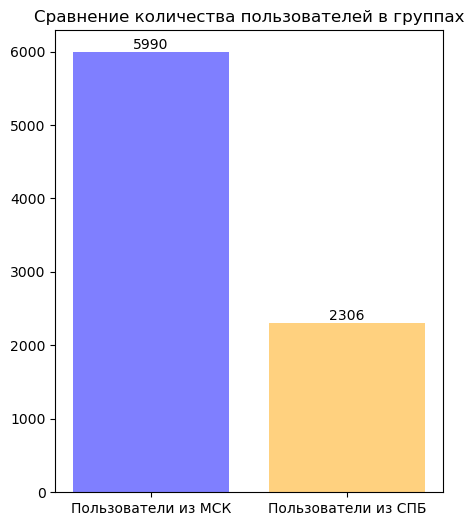

Процентная разница в количестве пользователей: 61.50%


In [12]:
a_group = df_test[df_test['group'] == 0]['number'].values[0]
b_group = df_test[df_test['group'] == 1]['number'].values[0]

# Рассчитываем процентную разницу
ratio_ab = abs(a_group - b_group) / a_group * 100


# Построение визуализации
plt.figure(figsize=(5, 6))
plt.bar(['Пользователи из МСК', 'Пользователи из СПБ'], [a_group, b_group], color=['blue', 'orange'], alpha=0.5)

# Добавление аннотаций с количеством пользователей для каждой группы
for i, value in enumerate([a_group, b_group]):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.ylabel('')
plt.xlabel('')

plt.title('Сравнение количества пользователей в группах')
plt.show()
print(f"Процентная разница в количестве пользователей: {ratio_ab:.2f}%")

Проверим, как различаются дисперсия в группах:

In [13]:
#Фуормируем 2 выборки данных
sample0 = df_all[df_all['group'] == 0]['hours'].values
sample1 = df_all[df_all['group'] == 1]['hours'].values

# Расчёт дисперсии
var_sample0 = np.var(sample0, ddof=1)  # ddof=1 для несмещённой оценки
var_sample1 = np.var(sample1, ddof=1)

print(f"Дисперсия первой выборки: {var_sample0}")
print(f"Дисперсия второй выборки: {var_sample1}")

# Тест Левена
stat, p = levene(sample0, sample1)
print(f"Статистика теста Левена: {stat}, p-значение: {p}")

if p > 0.05:
    print("Нет оснований отвергать нулевую гипотезу о равенстве дисперсий.")
else:
    print("Есть основания полагать, что дисперсии различаются.")


Дисперсия первой выборки: 1363.501557183273
Дисперсия второй выборки: 1586.5686735105937
Статистика теста Левена: 0.20246696398374836, p-значение: 0.6527486689965525
Нет оснований отвергать нулевую гипотезу о равенстве дисперсий.


**<p style="color: black; background-color: orange;">Вывод:</p>**
- Данные загружены и очищены корректно (удалены дубликаты по puid и лишний столбец).
- Пропусков и аномальных типов данных не обнаружено.
- Распределение активности в обеих группах схожее: большинство пользователей проводят менее часа, но есть выбросы, например 978 часов.
- Средняя активность в Санкт-Петербурге немного выше, чем в Москве, но разница несущественна.

## Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.
- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

**Для проверки гипотезы используем 2 теста:**
- t-тест
- Тест Манна — Уитни

Поскольку это метрика «на пользователя», которая не будет долей или отношением, можно утверждать, что она непрерывна. Это позволяет использовать для её анализа t-тест.
С другой стороны, тест Манна — Уитни помогает ответить на вопрос, в какой группе значения в среднем больше. Он помогает понять, различаются ли две группы. Так как в данных есть выбросы, то этот тест может показать выводы, отличающиеся от t-тест.

In [14]:
#зададим  уровень статистической значимости - alpha
alpha = 0.05

In [15]:
#проводим t-тест для проверки равенства средних
stat, p_value = ttest_ind(sample0, sample1, equal_var=False, alternative='less')
print(f'p-value = {round(p_value,3)}')

if p_value > 0.05:
    print("Нулевая гипотеза не отвергается: Средняя активность пользователей в двух группах не отличается.")
else:
    print("Нулевая гипотеза отвергается: Средняя активность пользователей в двух группах отличается.")

p-value = 0.332
Нулевая гипотеза не отвергается: Средняя активность пользователей в двух группах не отличается.


Тест Манна — Уитни помогает ответить на вопрос, в какой группе значения в среднем больше. Он помогает понять, различаются ли две группы по некоторой метрике, например, доходу, времени на сайте, кликам и так далее.

In [16]:
mw_test = mannwhitneyu(
    sample0, # Выборка значений метрики для группы А
    sample1, # Выборка значений метрики для группы B
    alternative='less' # двусторонняя гипотеза
                            # alternative='less' соответствует альтернативной гипотезе: Dist(a)<Dist(b)
                            # alternative='greater' соответствует альтернативной гипотезе: Dist(a)>Dist(b)
)
if mw_test.pvalue > alpha:
    print(f'pvalue={round(p_value,3)} > {alpha}')
    print('Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны')
else:
    print(f'pvalue={round(p_value,3)} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения! Распределения метрики в группах A и B различаются')

pvalue=0.332 > 0.05
Нулевая гипотеза находит подтверждение! Распределения метрики в группах A и B равны


## Аналитическая записка


- Выбранный тип t-теста и уровень статистической значимости.
- Результат теста, или p-value.
- Вывод на основе полученного p-value, то есть интерпретацию результатов.
- Одну или две возможные причины, объясняющие полученные результаты.

**<p style="color: black; background-color: orange;">Вывод по результатам A/B-теста:</p>**

Характеристики эксперимента: 
- Тест проводился на двух выборках — Группа А (пользователи из Москвы) и группа B (пользователи из Санкт-Петербурга). 
- Всего было проанализировано 5990 записей для группа А и 2306 записей для группы B.
- При оценке статистики двух групп, выбросов не обнаружено, дисперсии равны.

Цели и задачи эксперимента, ключевая метрика: 
- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.
- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.
- Выбранный тип теста: t-теста и тест Манна — Уитни
- Уровень статистической значимости: α = 0.05

Результаты эксперимента
- В группе A средняя активность пользователей 10.8 часов, стандартное отклонение 36.9.
- В группе B средняя активность пользователей 11.4 часов, стандартное отклонение 39.8.
- pvalue в t-тесте и тесте Манна — Уитни равны 0.332.
- Так как в обоих тестах pvalue > α, то нулевая гипотеза H₀ не отвергается, а именно: средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

**На основании проведенного эксперемента нельзя однозначно сделать вывод, что средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) как то отличается. 
Рекомендуется провести новый эксперимент, увеличив количество данных. 
Изначально в выборку вошли данные о пользователях, которые были как в Москве, так и в Сантк-Петербурге, которые при работе с данными были исключены из выборки. Возможно аналогичная картина происходит и с другими пользователями, которые могут пользоваться приложениям находясь в разных городах и тем самым "размазывая" свою активность по всем городам, то есть сглаживают различия.**

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

# 1. Цель и задачи исследования



Провести оценку результатов A/B-теста на основе анализа данных интернет-магазина спортивных товаров BitMotion Kit.
- Загрузить данные и ознакомиться с ними;
- Провести предобработку данных для дальнейшего анализа;
- Сформировать нулевую и альтернативную гипотезы;
- Сравнить распределение данных и статистики в тестовых группах;
- Оценить успешность нововведения.

Техническое задание проведённого теста
Предыдущий аналитик проверял полное обновление дизайна сайта. Гипотеза заключается в следующем: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

Параметры теста:
- название теста: interface_eu_test;
- группы: А (контрольная), B (новый интерфейс).

Нужно:
- загрузить данные теста;
- проверить корректность его проведения;
- проанализировать полученные результаты.

# Описание данных
Таблица с информацией об участниках тестов: https://code.s3.yandex.net/datasets/ab_test_participants.csv
- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.

Архив с информацией о собиытиях 2020 года: https://code.s3.yandex.net/datasets/ab_test_events.zip 
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии: `registration (регистрация)` — стоимость привлечения клиента; `purchase (покупка)` — стоимость покупки.

# 2. Загрузим данные, оценим их целостность.

In [17]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [18]:
#выводим первые и последние 5 строк датафрейма participants
display(participants)

#выводим общую информацию по датафрейму participants
participants.info()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
...,...,...,...,...
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC
14522,FFF28D02B1EACBE1,B,recommender_system_test,PC
14523,FFF28D02B1EACBE1,B,interface_eu_test,PC


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [19]:
#выводим первые и последние 5 строк датафрейма events
display(events)

#выводим общую информацию по датафрейму events
events.info()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
...,...,...,...,...
787281,1A655C280B064708,2020-12-31 23:57:44,product_page,NaN
787282,B77B2F4BCA134618,2020-12-31 23:58:23,registration,0.0
787283,GLOBAL,2020-12-31 23:58:30,product_cart,NaN
787284,B12AD1623E494FAD,2020-12-31 23:58:34,registration,-6.52


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


**<p style="color: black; background-color: orange;">Вывод:</p>**

Данные в `participants`  представлены 4 столбцами и 14525 строками:
- Столбцы названы корректно, в данных нет пропусков.
- `user_id`, `group`, `ab_test`, `device` имеют тип `object`, что является достаточным для задач исследования.          

Данные в датафрейме `events` представлены 4 столбцами и 787286 строками. 
- Столбцы названы корректно, типы данных корректны.
- Пропуски в данных наблюдаются в столбце `details`, содержащем детали о событии. Пропуски в этом столбце не являются критичными для исследования.
- `user_id`, `event_name`, `details` имеют тип `object`, что является достаточным для задач исследования.  
- `event_dt` имеет тип datetime64[ns], что также является достаточным для задач исследования.

# Проверка наличия дубликатов

In [20]:
for column in participants.columns:
    duplicates_count = participants[participants[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке user_id: 887
Количество дубликатов в колонке group: 14523
Количество дубликатов в колонке ab_test: 14523
Количество дубликатов в колонке device: 14521


In [21]:
unique_values1 = participants['group'].unique()
unique_values2 = participants['ab_test'].unique()
unique_values3 = participants['device'].unique()

print(f'Уникальные значения в group: {unique_values1}')
print(f'Уникальные значения в ab_test: {unique_values2}')
print(f'Уникальные значения в device: {unique_values3}')

Уникальные значения в group: ['B' 'A']
Уникальные значения в ab_test: ['interface_eu_test' 'recommender_system_test']
Уникальные значения в device: ['Mac' 'Android' 'iPhone' 'PC']


In [22]:
grouped_ab_test = participants.groupby('ab_test').size().reset_index(name='count')
sorted_device = grouped_ab_test.sort_values(by='count', ascending=False)
grouped_ab_test.head(20)

,ab_test,count
0,interface_eu_test,10850
1,recommender_system_test,3675


In [23]:
for column in events.columns:
    duplicates_count = events[events[column].duplicated()].shape[0]
    print(f"Количество дубликатов в колонке {column}: {duplicates_count}")

Количество дубликатов в колонке user_id: 643102
Количество дубликатов в колонке event_dt: 180713
Количество дубликатов в колонке event_name: 787278
Количество дубликатов в колонке details: 787116


Проверим, какие встречаются дубликаты в user_id и event_name.

In [24]:
grouped_user_id = events.groupby('user_id').size().reset_index(name='count')
sorted_user_id = grouped_user_id.sort_values(by='count', ascending=False)
sorted_user_id.head(5)

,user_id,count
144183,GLOBAL,58495
88517,A3917F81482141F2,35
26439,426330B820B8711A,31
62340,8AEB716C4CD82CA7,31
112787,BA87FD8D70D63CC6,31


In [25]:
grouped_event_name = events.groupby('event_name').size().reset_index(name='count')
sorted_event_name = grouped_event_name.sort_values(by='count', ascending=False)
sorted_event_name.head(20)

,event_name,count
3,login,248285
5,product_page,195606
7,registration,144183
6,purchase,104836
4,product_cart,94373
2,Start of Christmas&New Year Promo,1
0,End of Black Friday Ads Campaign,1
1,Start of CIS New Year Gift Lottery,1


**<p style="color: black; background-color: orange;">Вывод по `participants`:</p>**
**Данные в `participants`:**

**Дубликаты:**
- в `user_id`: 887
- в `group`: 14523
- в `ab_test`: 14523
- в `device`: 14521

**Уникальные значения (для данных с дубликатами которые повторяются):** 
- в `group`: A, B;
- в `ab_test`: interface_eu_test - 10403, recommender_system_test	- 3235;
- в `device`: Mac, Android, iPhone, PC;

**По итогу** Много дубликатов в user_id. Обратим на это внимание. Дубликатов в других данных также много, но это допустимо по специфики данных.
В `ab_test` есть два типа данных: `interface_eu_test` - 10403, `recommender_system_test` - 3235. Мы тестируем `interface_eu_test`, следовательно данные по `recommender_system_test` (3235 значений)  можем исключить.

**<p style="color: black; background-color: orange;">Вывод по `events`:</p>**
**Данные в датафрейме `events`:**

**Дубликаты:**
- в user_id: 643102
- в event_dt: 180713
- в event_name: 787278
- в details: 787116

**Уникальные значения (для данных с дубликатами которые повторяются):** 
- в `user_id` в большиниство дубликатов сформированы значением `GLOBAL` -	58495 значений.
- в `event_name`:
    - login	248285
    - product_page - 195606
    - registration - 144183
    - purchase - 104836
    - product_cart - 94373
    - Start of Christmas&New Year Promo - 1
    - End of Black Friday Ads Campaign - 1
    - Start of CIS New Year Gift Lottery - 1

**По итогу**: 
- вызывает подозрения в `user_id` 58495 дубликатов со значением `GLOBAL`;
- значения в `event_name` Start of Christmas&New Year Promo, End of Black Friday Ads Campaign, Start of CIS New Year Gift Lottery.

Обратим на этот факт внимание. Но на данном этапе эти дубликаты возможны и не являются ошибками в данных.

# 3. По таблице `participants` оценим корректность проведения теста:

Выделим пользователей, участвующих в тесте, и проверим:
   - соответствие требованиям технического задания,
   - равномерность распределения пользователей по группам теста,
   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

# 3.1 Проверим на отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

Убедимся, что среди пользователей теста интерфейса сайта нет пользователей, участвующих в других тестах.

In [26]:
# Создаем группы пользователей из групп разных тестов
interface_test = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
system_test = participants[participants['ab_test'] == 'recommender_system_test']['user_id']

# находим их пересечение (общих пользователей)
intersection = list(set(interface_test) & set(system_test))
if intersection == []:
    print('В тестовых группах interface_eu_test и recommender_system_test нет общих пользователей')
else:
    print(f"Количество пользователей который попали в оба теста: {len(intersection)}")

Количество пользователей который попали в оба теста: 887


Данные пользователи, участвуя в двух тестах одновременно, тем самым искажают результаты теста, так как нельзя точно сказать, какое именно изменение в работе продукта повлияло на их поведение. Удалим эти строки, чтобы не искажать результаты тестов.

In [27]:
# удаляем общие строки
participants.drop(index=participants.loc[participants['user_id']
                          .isin(intersection)].index, inplace=True)

# 3.2 Проверим на соответствие требованиям технического задания. 

In [28]:
# исключим recommender_system_test (3235 значений) из ab_test_participants:
participants = participants[participants['ab_test'] != 'recommender_system_test'].reset_index(drop=True)
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9963 entries, 0 to 9962
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  9963 non-null   object
 1   group    9963 non-null   object
 2   ab_test  9963 non-null   object
 3   device   9963 non-null   object
dtypes: object(4)
memory usage: 311.5+ KB


In [29]:
users_A = set(participants[participants['group'] == 'A']['user_id'])
users_B = set(participants[participants['group'] == 'B']['user_id'])

# Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B
intersection = list(set(users_A) & set(users_B))

if intersection == []:
    print('В группах А и В нет общих пользователей')
else:
    print(f"Количество пользователей который попали в обе группы А и В: {len(intersection)}")

В группах А и В нет общих пользователей


# 3.3 Проверим на равномерность распределения пользователей по группам теста


In [30]:
# Группируем пользователей по тестовым группам
ab_test_group = participants.groupby('group').agg({'user_id': 'count'}).reset_index()

display(ab_test_group)

# Рассчитываем процентную разницу
a_group = ab_test_group[ab_test_group['group'] == 'A']['user_id'].values[0]
b_group = ab_test_group[ab_test_group['group'] == 'B']['user_id'].values[0]
ratio_ab = abs(a_group - b_group) / a_group * 100
print(f"Процентная разница в количестве пользователей: {ratio_ab:.2f}%")

,group,user_id
0,A,4952
1,B,5011


Процентная разница в количестве пользователей: 1.19%


# 3.4 Проверим равномерность разделения пользователей в `participants` по device:


In [31]:
# Группируем данные по тестовой группе и региону
device_dist = participants.groupby(['group', 'device'])['user_id'].nunique().unstack()

# Нормализуем данные для отображения долей
device_dist_normalized = device_dist.div(device_dist.sum(axis=1), axis=0) * 100

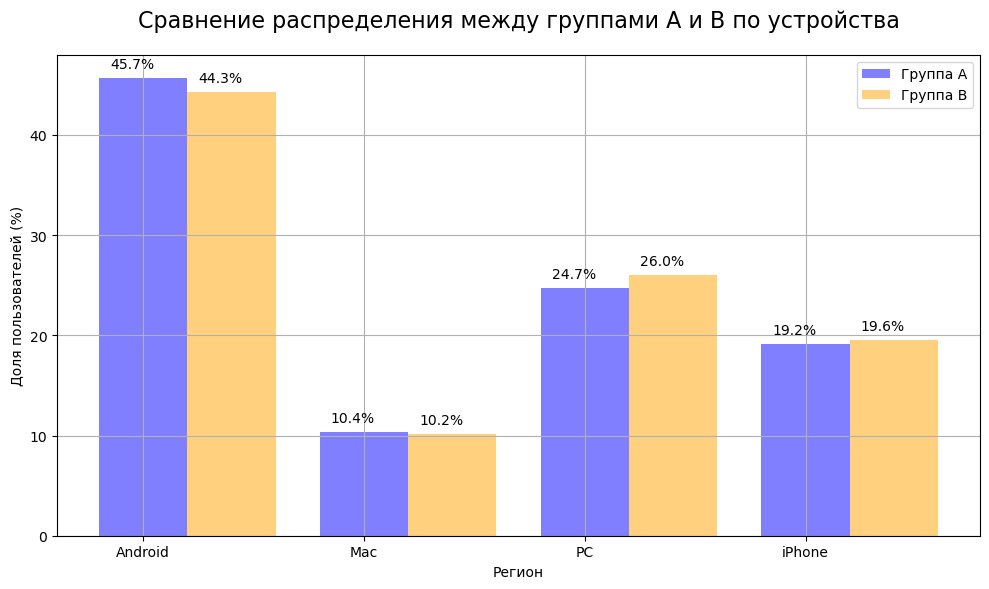

device,Android,Mac,PC,iPhone
group,,,,
A,45.72%,10.40%,24.70%,19.18%
B,44.26%,10.20%,25.98%,19.56%
Relative Difference A-B,-3.19%,-1.94%,5.21%,1.94%


In [32]:
plt.figure(figsize=(10, 6))  

# Создаём массив позиций для столбцов
x_positions_A = np.arange(len(device_dist_normalized.columns))
x_positions_B = x_positions_A + 0.4  # Сдвигаем позиции для второй группы

plt.bar(x_positions_A, device_dist_normalized.loc['A'], color='blue', label='Группа A', alpha=0.5, width=0.4)
plt.bar(x_positions_B, device_dist_normalized.loc['B'], color='orange', label='Группа B', alpha=0.5, width=0.4)

plt.title('Сравнение распределения между группами A и B по устройства', fontsize=16, pad=20)
plt.xlabel('Регион')
plt.ylabel('Доля пользователей (%)')
plt.xticks(x_positions_A, device_dist_normalized.columns)
plt.legend()
plt.grid(True)

# Добавляем значения на столбцы
for i, (a_val, b_val) in enumerate(zip(device_dist_normalized.loc['A'], device_dist_normalized.loc['B'])):
    plt.text(i - 0.05, a_val + 1, f'{a_val:.1f}%', ha='center')
    plt.text(i + 0.35, b_val + 1, f'{b_val:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# Вычисляем разницу между строками 1 и 2 для каждой колонки
difference = round((device_dist_normalized.iloc[1] - device_dist_normalized.iloc[0])/device_dist_normalized.iloc[0]*100,2)

# Добавляем новую строку с разницей в таблицу
device_dist_normalized.loc['Relative Difference A-B'] = difference
styled_df1 = device_dist_normalized.style.format('{:.2f}%')

display(styled_df1)

**<p style="color: black; background-color: orange;">Итоги: по `participants`:</p>**
- Было 14 525 строк, стало 9 963. Исключены данные, связанных с тестом `recommender_system_test`.
- В группах А и В не встречается пользователей, которые попали в обе группы.
- Группа A имеет 4952 пользователей. Группа B имеет 5011. Группа В на 1.19% больше, чем группа A.
- Тестовые группы имеют примерно равное количество участников и не должны исказить результаты А/В-теста.
- В данных представлено 4 типа устройств iPhone, Android, PC и MAC, при этом как можно заметить, что для обеих групп характерно практически равномерное распределение пользователей между устройствами, есть незначительные отличия: от 1.94% до 5.21% (в относительном выражении). То есть можно говорить, что по такой категориальной переменной как тип устройства пользователи распределены равномерно.

# 4. Проанализируем данные о пользовательской активности по таблице `events`:
Оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [33]:
# Список пользователей, участвующих в тесте 
unique_users = participants['user_id'].unique()
# Фильтруем события только для этих пользователей
events = events[events['user_id'].isin(unique_users)]

# 4.1 Определим горизонт анализа: 
рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [34]:
# Определяем дату регистрации
registration_dates = (
    events.loc[events['event_name'] == 'registration', ['user_id', 'event_dt']]
    .groupby('user_id', as_index=False, sort=False)
    .min()
    .rename(columns={'event_dt': 'registration_date'}))

In [35]:
# Оставляем только пользователей с регистрацией
events = events.merge(registration_dates, on='user_id', how='inner')

# Вычисляем разницу в часах
events['lifetime_hours'] = (events['event_dt'] - events['registration_date']).dt.total_seconds() / 3600

# Фильтруем события, произошедшие в первые 7 дней после регистрации включительно
events = events[events['lifetime_hours']<=168].reset_index(drop=True)
events.info()
display(events)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63805 entries, 0 to 63804
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            63805 non-null  object        
 1   event_dt           63805 non-null  datetime64[ns]
 2   event_name         63805 non-null  object        
 3   details            16125 non-null  object        
 4   registration_date  63805 non-null  datetime64[ns]
 5   lifetime_hours     63805 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 2.9+ MB


,user_id,event_dt,event_name,details,registration_date,lifetime_hours
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0.000000
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0.000000
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0.000000
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0.000000
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0.000000
...,...,...,...,...,...,...
63800,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,156.181944
63801,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,156.202222
63802,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,152.890833
63803,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,152.920278


**<p style="color: black; background-color: orange;">Итоги: по `events`:</p>**
- В датасете осталось 63 805   записей из 787 286, которые были изначально.
- Исключены данные, которые не связанны с участвующими в изучаемом тесте пользователями;
- Были оставлены только те события, которые выполнены в течение первых семи дней с момента регистрации.
- Были введены колонки `registration_date` `lifetime_hours`.

# 5. Оценим достаточность выборки для получения статистически значимых результатов A/B-теста.  

**Параметры для теста:**

- базовый показатель конверсии — 30%
- мощность теста — 80%
- достоверность теста — 95%
- MDE — 3% (предполагает ростся с 30% до 33%)

Найдем необходимый размер выборки для каждой группы.

In [36]:
# Зададим параметры теста:
p1 = 0.3  # базовый показатель конверсии
power = 0.8  # Мощность теста
alpha = 0.05  # Уровень значимости
mde = 0.03  # Минимальный детектируемый эффект

# Расчёт размера выборки
effect_size = proportion_effectsize(p1, p1 + mde)

print(effect_size)

-0.06459994854032636


In [37]:
# Инициализируем класс NormalIndPower 
power_analysis = NormalIndPower()
# Расчёт размера выборки 
sample_size = power_analysis.solve_power( 
    effect_size = effect_size, 
    power = power, 
    alpha = alpha, 
    ratio = 1 # Равномерное распределение выборок
)
print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


**<p style="color: black; background-color: orange;">Вывод:</p>**
Размер используемых выборок превышаете минимальный требуемый объем, соответственно данных достаточно для проведения тестирования внедрения нового интерфейса.

# 6. Анализ данных о пользовательской активности
 рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [38]:
# Находим пользователей из тестовых групп
a_group =  participants[participants['group'] == 'A']
b_group =  participants[participants['group'] == 'B']

# Считаем число посетителей из каждой группы
a_visitors_total = a_group['user_id'].nunique()
b_visitors_total = b_group['user_id'].nunique()

# Находим сколько всего посетителей сделали покупку
buyers = events[events['event_name'] == 'purchase']['user_id']
buyers_set = set(buyers)

a_visitors_set = set(a_group['user_id'])
b_visitors_set = set(b_group['user_id'])

In [39]:
# Находим количество покупателей в каждой группе
a_buyers_count = len(buyers_set & a_visitors_set)
b_buyers_count = len(buyers_set & b_visitors_set)

# Составляем таблицу для удобной визуализации
data = {
    'Группа': ['A', 'B'],
    'Общее кол-во посетителей': [a_visitors_total, b_visitors_total],
    'Кол-во покупателей': [a_buyers_count, b_buyers_count],
    'Конверсия': [round((a_buyers_count / a_visitors_total), 2), round((b_buyers_count / b_visitors_total), 2)]
}

# Преобразуем в DataFrame
result_df = pd.DataFrame(data)
result_df


,Группа,Общее кол-во посетителей,Кол-во покупателей,Конверсия
0,A,4952,1377,0.28
1,B,5011,1480,0.30


**<p style="color: black; background-color: orange;">Вывод:</p>**
- Количество пользователей, участвующих в тесте, превышает минимальное количество, которое требуется для корректного теста.
- Разница по количеству пользователей между группами А и В незначительно (1.19%),
- Количество покупателей в группе В больше, чем в А.
- Конверсия в группе А - 0,28%, в В - 0,30%, что может указывать на успешность упрощения интерфейса.

# 7. Проведем оценку результатов A/B-тестирования:

Формулировка нулевой и альтернативной гипотез:

**Гипотеза:** 
Упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта

**Нулевая гипотеза (H₀):** Конверсия зарегистрированных пользователей в покупателей в течение семи дней после регистрации в обеих группах не различаются;

**Альтернативная гипотеза (H₁):** Упрощение интерфейса приводит к тому, что конверсия зарегистрированных пользователей в покупателей в течение семи дней после регистрации в группе B будет выше по сравнению с группой А.

Конверсия является долевым показателем, для оценки результатов тестирования используем **Z-тест пропорций**.


# 7.1 Проверим, что данных достаточно для Z-тест

In [40]:
## посчитаем размер групп (данные взяты с прошлого шага)
n_a = a_visitors_total
n_b = b_visitors_total

##посчитаем количество успешных исходов для групп
m_a = a_buyers_count
m_b = b_buyers_count

## считаем конверсию
p_a, p_b = m_a/n_a, m_b/n_b

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных не выполняется!')

Предпосылка о достаточном количестве данных выполняется!


# 7.2 Использование Z-теста

In [41]:
alpha = .05

stat_ztest, p_value_ztest = proportions_ztest([m_a,m_b],
                                              [n_a,n_b],
                                              alternative='smaller')
print(f'p-value теста Z-пропорции = {round(p_value_ztest,5)}')

if p_value_ztest>alpha:
    print('Нулевую гипотезу не отвергаем: нет оснований говорить о том, что изменение интерфейса повлияло на конверсию продаж')
    print()
else:
    print('Принимаем альтернативную гипотезу: изменение интерфейса повлияло на конверсию продаж')

p-value теста Z-пропорции = 0.02826
Принимаем альтернативную гипотезу: изменение интерфейса повлияло на конверсию продаж


# 8. Итоги анализа результатов A/B-тестирования


Цель эксперимента: 
- проверить гипотезу, что упрощение интерфейса интернет-магазина BitMotion Kit привело к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличилась как минимум на три процентных пункта.

Характеристики эксперимента: 
- Минимальный расчетный размер выборки для A/B теста составил 3 761 записей для каждой группы. 
- Эксперимент проводился на двух группах пользователей — A (контрольная) и B (тестовая). 
- Всего было проанализировано 9 963 записей. 

Цели и задачи эксперимента, ключевая метрика: 
- Ключевая метрика — конверсия от регистрации до покупки продукта в интернет-магазине.
- Нулевая гипотеза (H₀): Конверсия зарегистрированных пользователей в покупателей в течение семи дней после регистрации в обеих группах не различаются;
- Альтернативная гипотеза (H₁): Упрощение интерфейса приводит к тому, что конверсия зарегистрированных пользователей в покупателей в течение семи дней после регистрации в группе B будет выше по сравнению с группой А.
- Прокси-материки и барьерные материки не применялись

Результаты эксперимента
- В группе A конверсия составила 28%, а в группе B — 30%. 
- Разница между группами составила ~2%, то есть предполагаем, что конверсия после внедрения нового интерфейсас вырасла.

Статистическая значимость: 
- Z-тест показал p-value ≈ 0.0085
- Поскольку p-value < alpha (alpha = 0.05), то изменение интерфейса действительно повлияло на конверсию продаж и оно статистически значимо.

Выводов эксперимента:
- Существует статистически значимое различие между конверсией зарегистрированных пользователей в покупателей в группах A и B.
Поскольку альтернативная гипотеза утверждала, что конверсия в группе А меньше, чем в группе B, результаты подтверждают это предположение. Полное обновление дизайна сайта с упрощением интерфейса действительно привело к росту покупок на сайте.
- С другой стороны, конверсия в контрольной группе составила 28%, в тестовой - 30%. С учетом, что уровень конверсии в 30%, который брался как базовый для контрольной группы, достигнут только в тестовой группе, то считаем, что исходные данные эсперимента содержали завышенную оценку исходных данных.    
- Ошибка в исходных данных, может означать, что какие то данные при анализе прошлым аналитиком были учтены или интерпретированы некорректно, что могло в целом повлиять на хоть эксперимента. Например был не учтен фактор сезонности, различий по регионам пользователей, маркетинговые акции и скидки для отдельных регионов или каналов продаж, или были допущены технические ошибки при сборе данных.  

Рекомендации:
- С связи с завышенной оценкой конверсии в контрольной группе, рекомендуется повторный эсперимент и провести анализ конверсии зарегистрированных пользователей в покупателей на новых исторических данных. 